In [1]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")
#import seaborn as sns

# Data Science
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets
import xarray as xr

# Geospatial raster data handling
import rioxarray as rxr

# Geospatial data analysis
#import geopandas as gpd

# Geospatial operations
import rasterio
from rasterio import windows  
from rasterio import features  
from rasterio import warp
from rasterio.warp import transform_bounds 
from rasterio.windows import from_bounds 

# Image Processing
from PIL import Image

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
import tf_keras as keras  # Use tf_keras instead of tf.keras
from tf_keras import layers
from tf_keras.models import Model, Sequential, load_model
from tf_keras.layers import Input, Dropout, Dense
from tf_keras.optimizers import Adam
import tensorflow_probability as tfp
import tensorflow_probability.python.layers as tfpl
tfd = tfp.distributions
tfb = tfp.bijectors
from tf_keras.callbacks import CSVLogger, ModelCheckpoint

# Planetary Computer Tools
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# Others
import os
from tqdm import tqdm
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

2025-05-06 15:29:34.324600: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [4]:
# Extracts satellite band values from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.

def map_satellite_data(tiff_path, csv_path):
    
    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    # 3. Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_tiff = Proj(tiff_crs)
    
    # Create a transformer object
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    vals = [[] for _ in range(n_inputs)]


# Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)
    
        for i in range(n_inputs):
            tmp = data.sel(x=lon, y=lat, band=i, method='nearest').values
            vals[i].append(tmp)

    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    df = pd.DataFrame()
    for i in range(n_inputs):
        df[names[i]] = vals[i]
    
    return df


In [45]:
# Constants
n_inputs = 28
names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12", "ndwi", "ndvi", "ndbi", 
        "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)", "B12 (pooled)", "ndwi (pooled)", "ndvi (pooled)", "ndbi (pooled)",
        "building_count_0-25ft", "building_impact_0-25ft", "building_count_25-50ft", "building_impact_25-50ft", "building_count_50-100ft", "building_impact_50-100ft", "building_count_100-200ft", "building_impact_100-200ft", "building_count_200-500ft", "building_impact_200-500ft",
        "tree_count_0-25ft", "tree_impact_0-25ft", "tree_count_25-50ft", "tree_impact_25-50ft", "tree_count_50-100ft", "tree_impact_50-100ft", "tree_count_100-200ft", "tree_impact_100-200ft", "tree_count_200-500ft", "tree_impact_200-500ft",
        "closest_building_height", "closest_building_area", "closest_tree_dbh",
   #contains nans     #"closest_building_distance", "closest_tree_distance",
   #contains nans     #"B02_ring1_mean", "B02_ring1_std", "B03_ring1_mean", "B03_ring1_std", "B04_ring1_mean", "B04_ring1_std", "B08_ring1_mean", "B08_ring1_std", "B11_ring1_mean", "B11_ring1_std", "B12_ring1_mean", "B12_ring1_std", "ndvi_ring1_mean", "ndvi_ring1_std", "ndbi_ring1_mean", "ndbi_ring1_std", "ndwi_ring1_mean", "ndwi_ring1_std"
        ]
UhiData_FileName = "Data/Training_data_uhi_index.csv"
satellite_data =  "Data/S2_median_fullBands_indeces.tiff"
tree_building_uhi_data = "Data/LATEST_combined_tree_building_uhi_features.csv"
complete_data = "Data/complete_uhi_satellite_data_20250504_225131.csv"
test_size = 0.3

# Open the GeoTIFF file
tiff_path = "Data/S2_median_fullBands_indeces.tiff"

# Read the bands from the GeoTIFF file
with rasterio.open(tiff_path) as src1:
    cols = [src1.read(i) for i in range(1, n_inputs+1)]

In [46]:
# Would be faster in a df
#feature_data = map_satellite_data(satellite_data, UhiData_FileName)
feature_data = pd.read_csv(complete_data)

In [47]:
# Redo columns
'''
feature_data["ndwi"] = (feature_data["B03"] - feature_data["B08"])/(feature_data["B03"] + feature_data["B08"]) #Normalized Difference Water Index
feature_data["ndbi"] = (feature_data["B11"] - feature_data["B08"])/(feature_data["B11"] + feature_data["B08"]) # Normalized Difference Buildup Index
feature_data["ndvi"] = (feature_data["B08"] - feature_data["B04"])/(feature_data["B08"] + feature_data["B04"]) #Normalized Difference Vegetation Index
feature_data["ndwi (pooled)"] = (feature_data["B03 (pooled)"] - feature_data["B08 (pooled)"])/(feature_data["B03 (pooled)"] + feature_data["B08 (pooled)"]) #Normalized Difference Water Index
feature_data["ndbi (pooled)"] = (feature_data["B11 (pooled)"] - feature_data["B08 (pooled)"])/(feature_data["B11 (pooled)"] + feature_data["B08 (pooled)"]) # Normalized Difference Buildup Index
feature_data["ndvi (pooled)"] = (feature_data["B08 (pooled)"] - feature_data["B04 (pooled)"])/(feature_data["B08 (pooled)"] + feature_data["B04 (pooled)"]) #Normalized Difference Vegetation Index

feature_data['ndvi'] = feature_data['ndvi'].replace([np.inf, -np.inf], np.nan) 
feature_data['ndwi'] = feature_data['ndwi'].replace([np.inf, -np.inf], np.nan) 
feature_data['ndbi'] = feature_data['ndbi'].replace([np.inf, -np.inf], np.nan)
feature_data['ndvi (pooled)'] = feature_data['ndvi (pooled)'].replace([np.inf, -np.inf], np.nan) 
feature_data['ndwi (pooled)'] = feature_data['ndwi (pooled)'].replace([np.inf, -np.inf], np.nan) 
feature_data['ndbi (pooled)'] = feature_data['ndbi (pooled)'].replace([np.inf, -np.inf], np.nan) 
'''

'\nfeature_data["ndwi"] = (feature_data["B03"] - feature_data["B08"])/(feature_data["B03"] + feature_data["B08"]) #Normalized Difference Water Index\nfeature_data["ndbi"] = (feature_data["B11"] - feature_data["B08"])/(feature_data["B11"] + feature_data["B08"]) # Normalized Difference Buildup Index\nfeature_data["ndvi"] = (feature_data["B08"] - feature_data["B04"])/(feature_data["B08"] + feature_data["B04"]) #Normalized Difference Vegetation Index\nfeature_data["ndwi (pooled)"] = (feature_data["B03 (pooled)"] - feature_data["B08 (pooled)"])/(feature_data["B03 (pooled)"] + feature_data["B08 (pooled)"]) #Normalized Difference Water Index\nfeature_data["ndbi (pooled)"] = (feature_data["B11 (pooled)"] - feature_data["B08 (pooled)"])/(feature_data["B11 (pooled)"] + feature_data["B08 (pooled)"]) # Normalized Difference Buildup Index\nfeature_data["ndvi (pooled)"] = (feature_data["B08 (pooled)"] - feature_data["B04 (pooled)"])/(feature_data["B08 (pooled)"] + feature_data["B04 (pooled)"]) #Norm

In [48]:
# Combining ground data and feature data into a single dataset.
'''
ground_df = pd.read_csv(UhiData_FileName)
tree_building_df = pd.read_csv(tree_building_uhi_data)
uhi_data = combine_two_datasets(ground_df,feature_data)
uhi_data = combine_two_datasets(uhi_data, tree_building_df)
'''

'\nground_df = pd.read_csv(UhiData_FileName)\ntree_building_df = pd.read_csv(tree_building_uhi_data)\nuhi_data = combine_two_datasets(ground_df,feature_data)\nuhi_data = combine_two_datasets(uhi_data, tree_building_df)\n'

In [49]:
# Remove duplicate rows from the DataFrame based on specified columns and keep the first occurrence
columns_to_check = ['B01','B04','B06','B08','ndvi']
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    uhi_data[col] = uhi_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

# Now remove duplicates
uhi_data = uhi_data.drop_duplicates(subset=columns_to_check, keep='first')
uhi_data.head()

,Longitude_features,Latitude_features,datetime_features,UHI Index_features,original_index,B01,B02,B03,B04,B05,...,B11_ring1_std,B12_ring1_mean,B12_ring1_std,ndvi_ring1_mean,ndvi_ring1_std,ndbi_ring1_mean,ndbi_ring1_std,ndwi_ring1_mean,ndwi_ring1_std,join_timestamp
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,0,841.5,1053.0,1155.0,1206.0,1481.5,...,774.912558,1904.014072,899.852967,2086.388859,1023.962242,2062.630733,1101.165704,2138.822302,1086.925480,2025-05-04 22:51:31
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,2,841.5,646.0,823.0,777.0,1130.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,3,841.5,625.0,766.0,741.5,1130.5,...,774.841262,1903.993142,899.857834,2086.408900,1024.015031,2062.672583,1101.215154,2138.858813,1086.997634,2025-05-04 22:51:31
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,4,841.5,659.5,763.0,708.5,1077.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
6,-73.909312,40.812710,24-07-2021 15:53,1.015143,6,841.5,551.5,768.5,659.0,1077.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31


In [50]:
# Load data, normalize distributions
#model_data = uhi_data[names + ['UHI Index']]
model_data = uhi_data[names + ['UHI Index_features']]
md_data_std = model_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0) 
md_data_std =md_data_std.apply(lambda x: pd.to_numeric(x, errors = 'coerce'), axis=0) 
nan_columns = md_data_std.columns[md_data_std.isna().any()]
print("Columns with NaNs:", list(nan_columns))

Columns with NaNs: []


In [51]:
# Divide data into training and testing
#X = md_data_std.drop(columns=['UHI Index']).values
#y = md_data_std['UHI Index'].values
X = md_data_std.drop(columns=['UHI Index_features']).values
y = md_data_std['UHI Index_features'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state=123)
print(X_train.shape) 
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_train.dtype, y_train.dtype)
print(np.min(X_train), np.max(X_train))
print(np.min(y_train), np.max(y_train))

(5852, 51)
(5852,)
(2509, 51)
(2509,)
float64 float64
-3.9434569811089957 46.41123200771299
-2.6966373156427044 2.838589501713187


In [55]:
def test_model(model, X_test, y_test, csv_name, model_name):
    
    # predict; get mse, r2
    #y_test = np.array([val[0] for val in y_test])
    y_pred = model.predict(X_test).flatten()
    print(f"MSE: {mean_squared_error(y_test, y_pred)}")
    print(f"r2: {r2_score(y_test, y_pred)}")

    # plotting loss curve
    log = pd.read_csv(csv_name)
    training_loss = log["loss"]
    validation_loss = log["val_loss"]
    plt.plot(np.arange(1, len(training_loss) + 1), training_loss, label="Training")
    plt.plot(np.arange(1, len(validation_loss) + 1), validation_loss, label="Validation")
    plt.legend(loc="upper right")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig(f"../Plots/{model_name}_loss")
    plt.clf()

    # plotting test vs pred dist
    plt.hist(
        y_test,
        bins=100,
        label='Actual',
        density=1,
        histtype="step",
    )
    plt.hist(
        y_pred,
        bins=100,
        label='Predicted',
        density=1,
        histtype="step",
    )
    plt.legend(loc="upper right")
    plt.xlabel("UHI Index")
    plt.ylabel("Frequency")
    plt.xlim(-3, 3)
    plt.savefig(f"../Plots/{model_name}_dist")
    plt.clf()
    
    # scatter plot of test vs pred
    plt.scatter(y_test, y_pred, s = 25, alpha=0.3)
    plt.xlabel("Actual UHI")
    plt.ylabel("Predicted UHI")
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    plt.savefig(f"../Plots/{model_name}_scatter")
    plt.clf()


In [53]:
# Standard Model
model1 = Sequential([
    Dense(64, activation = 'relu', input_shape=(51,) ),
    Dropout(0.1),
    Dense(64, activation = 'relu'),
    Dropout(0.1),
    Dense(64, activation = 'relu'),
    Dropout(0.1),
    Dense(1, activation = 'linear'),
])
model1.compile(optimizer=Adam(learning_rate=0.001) , loss = "MSE")
mc = ModelCheckpoint("Model_Stats/NN_model", save_best_only=True)
log = CSVLogger("Model_Stats/NN_training.log", append=True)
model1.fit(X_train, y_train, epochs=100, validation_split=0.1, callbacks=[mc, log], verbose=1)

Epoch 1/100
165/165 [==============================] - 4s 13ms/step - loss: 0.8591 - val_loss: 0.7607
Epoch 2/100
165/165 [==============================] - 1s 9ms/step - loss: 0.7240 - val_loss: 0.6958
Epoch 3/100
165/165 [==============================] - 1s 9ms/step - loss: 0.6742 - val_loss: 0.6616
Epoch 4/100
165/165 [==============================] - 1s 8ms/step - loss: 0.6366 - val_loss: 0.6265
Epoch 5/100
165/165 [==============================] - 1s 7ms/step - loss: 0.6202 - val_loss: 0.6233
Epoch 6/100
165/165 [==============================] - 1s 8ms/step - loss: 0.5910 - val_loss: 0.6050
Epoch 7/100
165/165 [==============================] - 1s 8ms/step - loss: 0.5751 - val_loss: 0.5885
Epoch 8/100
165/165 [==============================] - 1s 9ms/step - loss: 0.5697 - val_loss: 0.5820
Epoch 9/100
165/165 [==============================] - 2s 13ms/step - loss: 0.5437 - val_loss: 0.5737
Epoch 10/100
165/165 [==============================] - 1s 9ms/step - loss: 0.5297 - val_

In [56]:
test_model(load_model("Model_Stats/NN_model"), X_test=X_test, y_test=y_test, csv_name = "Model_Stats/NN_training.log", model_name = "NN")

79/79 [==============================] - 1s 2ms/step
MSE: 0.3425616035493975
r2: 0.6580033063687426


<Figure size 1000x1000 with 0 Axes>

In [ ]:
# Fixed prior: standard normal, wrapped in Independent
def prior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    # Use a MultivariateNormalDiag with a shared trainable covariance or set it manually.
    loc = tf.zeros(n)
    scale_tril = tf.linalg.cholesky(tf.eye(n))  # Identity = uncorrelated, but you can change this
    return Sequential([
        tfpl.DistributionLambda(
            lambda t: tfd.MultivariateNormalTriL(loc=loc, scale_tril=scale_tril)
        )
    ])

# Posterior: learnable multivariate Gaussian
def posterior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return Sequential([
        tfpl.VariableLayer(tfp.layers.MultivariateNormalTriL.params_size(n), dtype=dtype),
        tfpl.MultivariateNormalTriL(n)
    ])

In [70]:
# Bayesian Model
kl_weight = 1 / X_train.shape[0]  # or start with 1e-4
inputs = Input(shape=(51,))
x = tfp.layers.DenseVariational(
    units=16,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight = kl_weight,
    activation='sigmoid')(inputs)
outputs = Dense(1, activation='linear')(x)

# wider/deeper network still leads to posterior collapse
'''x = tfp.layers.DenseVariational(
    units=64,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight=kl_weight,
    activation='relu')(inputs)
x = tfp.layers.DenseVariational(
    units=32,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight=kl_weight,
    activation='relu')(x)
outputs = Dense(1, activation='linear')(x)'''

model2 = Model(inputs=inputs, outputs=outputs)
model2.compile(optimizer=Adam(0.001), loss="mse")
mc = ModelCheckpoint("Model_Stats/BNN_model", save_best_only=True)
log = CSVLogger(f"Model_Stats/BNN_training.log", append=True)
model2.fit(X_train, y_train, epochs=20, validation_split=0.1, callbacks=[mc, log], verbose=1)

Epoch 1/20
165/165 [==============================] - 7s 30ms/step - loss: 1.2943 - val_loss: 1.2607
Epoch 2/20
165/165 [==============================] - 5s 29ms/step - loss: 1.1322 - val_loss: 1.0447
Epoch 3/20
165/165 [==============================] - 2s 11ms/step - loss: 1.0364 - val_loss: 1.0655
Epoch 4/20
165/165 [==============================] - 5s 28ms/step - loss: 0.9861 - val_loss: 1.0284
Epoch 5/20
165/165 [==============================] - 5s 30ms/step - loss: 0.9488 - val_loss: 0.9901
Epoch 6/20
165/165 [==============================] - 2s 10ms/step - loss: 0.9273 - val_loss: 1.0100
Epoch 7/20
165/165 [==============================] - 5s 28ms/step - loss: 0.9306 - val_loss: 0.9606
Epoch 8/20
165/165 [==============================] - 2s 13ms/step - loss: 0.9281 - val_loss: 0.9987
Epoch 9/20
165/165 [==============================] - 5s 30ms/step - loss: 0.9199 - val_loss: 0.9494
Epoch 10/20
165/165 [==============================] - 2s 13ms/step - loss: 0.9031 - val_lo

In [80]:
test_model(load_model("Model_Stats/BNN_model"), X_test=X_test, y_test=y_test, csv_name = "Model_Stats/BNN_training.log", model_name = "BNN")


79/79 [==============================] - 0s 2ms/step
MSE: 0.8842721054870498
r2: 0.11718612590125654


<Figure size 1000x1000 with 0 Axes>

In [126]:
# Assume independence
def prior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    # Prior is a diagonal Gaussian for independence
    loc = tf.zeros(n)
    scale_diag = tf.ones(n)  # This is for the standard deviation (or use learnable scale)
    return Sequential([
        tfpl.DistributionLambda(
            lambda t: tfd.Independent(
                tfd.Normal(loc=loc, scale=scale_diag),
                reinterpreted_batch_ndims=1)
        )
    ])

def posterior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return Sequential([
        tfpl.VariableLayer(tfp.layers.IndependentNormal.params_size(n), dtype=dtype),
        tfpl.IndependentNormal(n)
    ])

In [127]:
# Independent bayesian Model
kl_weight = 1 / X_train.shape[0]  # or start with 1e-4
inputs = Input(shape=(51,))
x = tfp.layers.DenseVariational(
    units=16,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight = kl_weight,
    activation='sigmoid')(inputs)
outputs = Dense(1, activation='linear')(x)

model2a = Model(inputs=inputs, outputs=outputs)
model2a.compile(optimizer=Adam(0.001), loss="mse")
mc = ModelCheckpoint("Model_Stats/BNN_independent_model", save_best_only=True)
log = CSVLogger(f"Model_Stats/BNN_independent_training.log", append=True)
model2a.fit(X_train, y_train, epochs=20, validation_split=0.1, callbacks=[mc, log], verbose=1)

Epoch 1/20
165/165 [==============================] - 8s 27ms/step - loss: 1.1154 - val_loss: 1.1251
Epoch 2/20
165/165 [==============================] - 3s 17ms/step - loss: 0.9941 - val_loss: 1.0563
Epoch 3/20
165/165 [==============================] - 3s 16ms/step - loss: 0.9783 - val_loss: 1.0017
Epoch 4/20
165/165 [==============================] - 3s 16ms/step - loss: 0.9258 - val_loss: 0.9374
Epoch 5/20
165/165 [==============================] - 0s 3ms/step - loss: 0.9052 - val_loss: 0.9433
Epoch 6/20
165/165 [==============================] - 3s 17ms/step - loss: 0.8882 - val_loss: 0.8750
Epoch 7/20
165/165 [==============================] - 0s 2ms/step - loss: 0.8594 - val_loss: 0.8838
Epoch 8/20
165/165 [==============================] - 1s 3ms/step - loss: 0.8671 - val_loss: 0.9050
Epoch 9/20
165/165 [==============================] - 3s 15ms/step - loss: 0.8567 - val_loss: 0.8634
Epoch 10/20
165/165 [==============================] - 0s 3ms/step - loss: 0.8456 - val_loss: 

In [128]:
test_model(load_model("Model_Stats/BNN_independent_model"), X_test=X_test, y_test=y_test, csv_name = "Model_Stats/BNN_independent_training.log", model_name = "BNN_independent")

79/79 [==============================] - 0s 2ms/step
MSE: 0.8368260284604251
r2: 0.16455396076877327


<Figure size 1000x1000 with 0 Axes>

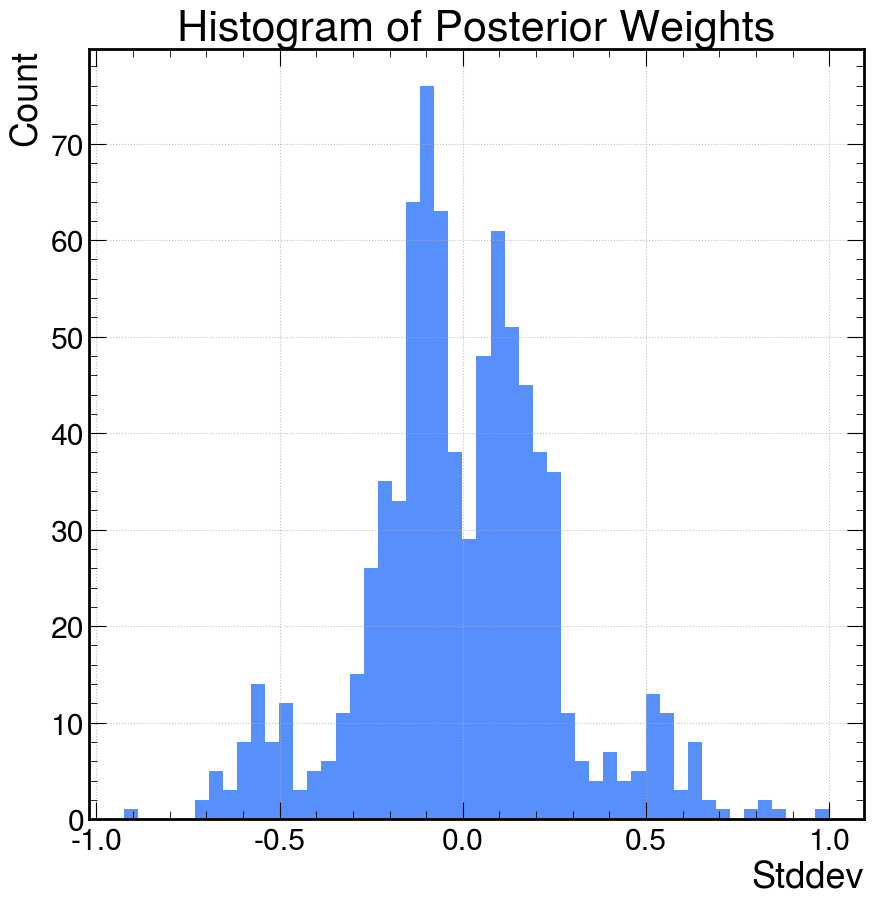

In [ ]:
dense_var_layer = [layer for layer in model2a.layers if isinstance(layer, tfp.layers.DenseVariational)][0]

# Now the posterior exists
weights = dense_var_layer.get_weights()[0]

# Sizes
kernel_size = 51 * 16  # = 816
bias_size = 16
total_size = kernel_size + bias_size  # = 832

# Extract means
kernel_mean = weights[:kernel_size]
bias_mean = weights[kernel_size:total_size]

# Extract raw stddevs (rho)
kernel_rho = weights[total_size:total_size + kernel_size]
bias_rho = weights[total_size + kernel_size:]

plt.hist(kernel_mean, bins=50)
plt.title("Histogram of Posterior Weights")
plt.xlabel("Stddev")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [61]:
# Now try pretraining BNN
model3_pre = Sequential([
    Dense(16, activation = 'sigmoid', input_shape=(51,) ),
    Dense(1, activation = 'linear'),
])
model3_pre.compile(optimizer=Adam(learning_rate=0.001) , loss = "MSE" )
mc = ModelCheckpoint("Model_Stats/NN_pretrained_model", save_best_only=True)
log = CSVLogger(f"Model_Stats/NN_pretrained_training.log", append=True)
model3_pre.fit(X_train, y_train, epochs=100, validation_split=0.1, callbacks=[mc, log], verbose=0)

In [62]:
test_model(load_model("Model_Stats/NN_pretrained_model"), X_test=X_test, y_test=y_test, csv_name = "Model_Stats/NN_pretrained_training.log", model_name = "NN_pretrained")

79/79 [==============================] - 0s 1ms/step
MSE: 0.5636582347272996
r2: 0.43727128020939954


<Figure size 1000x1000 with 0 Axes>

In [ ]:
def pretrained_prior(pretrained_model):
    def prior_fn(kernel_size, bias_size=0, dtype=None):
        n = kernel_size + bias_size
        prior_weights = pretrained_model.get_weights()  # This gives a list of numpy arrays

        # manually extract matching weights for each layer
        # assume layer order matches
        weight_index = prior_fn.layer_index
        prior_mean = tf.convert_to_tensor(
            prior_weights[weight_index].flatten().tolist() + 
            prior_weights[weight_index + 1].flatten().tolist(), dtype=dtype)
        prior_fn.layer_index += 2  # Advance to next layer’s weights

        # Define fixed Gaussian prior centered on pretrained weights
        return Sequential([
            tfpl.DistributionLambda(lambda t: tfd.Independent(
                tfd.Normal(loc=prior_mean, scale=0.05),  # small variance
                reinterpreted_batch_ndims=1))
        ])
    prior_fn.layer_index = 0
    return prior_fn

def pretrained_posterior(pretrained_model):
    def posterior_fn(kernel_size, bias_size=0, dtype=None):
        n = kernel_size + bias_size
        posterior_weights = pretrained_model.get_weights()

        # Layer index used to extract weights layer-by-layer
        weight_index = posterior_fn.layer_index
        posterior_mean = tf.convert_to_tensor(
            posterior_weights[weight_index].flatten().tolist() + 
            posterior_weights[weight_index + 1].flatten().tolist(), dtype=dtype)
        posterior_fn.layer_index += 2  # move to next layer

        # Default initialization for scale (lower-triangular Cholesky factor)
        def initializer_fn(shape, dtype=None):
            # Mean + unconstrained scale (init to identity)
            loc = posterior_mean
            tril_elements = tf.zeros(tfpl.MultivariateNormalTriL.params_size(n) - n, dtype=dtype)
            return tf.concat([loc, tril_elements], axis=0)

        return Sequential([
            tfpl.VariableLayer(tfp.layers.MultivariateNormalTriL.params_size(n),
                               dtype=dtype,
                               initializer=initializer_fn),
            tfpl.MultivariateNormalTriL(n)
        ])

    posterior_fn.layer_index = 0
    return posterior_fn


In [65]:
# Pretrained bayesian Model
prior = pretrained_prior(load_model("Model_Stats/NN_pretrained_model"))
posterior = pretrained_posterior(load_model("Model_Stats/NN_pretrained_model"))
kl_weight = 1 / X_train.shape[0]  # or start with 1e-4
inputs = Input(shape=(51,))
x = tfp.layers.DenseVariational(
    units=16,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight = kl_weight,
    activation='sigmoid')(inputs)
outputs = Dense(1, activation='linear')(x)

model3 = Model(inputs=inputs, outputs=outputs)
model3.compile(optimizer=Adam(0.001), loss="mse")
mc = ModelCheckpoint("Model_Stats/BNN_after_pretraining_model", save_best_only=True)
log = CSVLogger(f"Model_Stats/BNN_after_pretraining_training.log", append=True)
model3.fit(X_train, y_train, epochs=20, validation_split=0.1, callbacks=[mc, log], verbose=1)

Epoch 1/20
165/165 [==============================] - 6s 25ms/step - loss: 14.4264 - val_loss: 14.5653
Epoch 2/20
165/165 [==============================] - 4s 23ms/step - loss: 14.0351 - val_loss: 13.6215
Epoch 3/20
165/165 [==============================] - 4s 26ms/step - loss: 13.4518 - val_loss: 12.9936
Epoch 4/20
165/165 [==============================] - 4s 25ms/step - loss: 12.6928 - val_loss: 12.4791
Epoch 5/20
165/165 [==============================] - 4s 23ms/step - loss: 11.9633 - val_loss: 11.6081
Epoch 6/20
165/165 [==============================] - 4s 22ms/step - loss: 11.0299 - val_loss: 10.8002
Epoch 7/20
165/165 [==============================] - 4s 23ms/step - loss: 10.4464 - val_loss: 10.1797
Epoch 8/20
165/165 [==============================] - 4s 23ms/step - loss: 9.7151 - val_loss: 9.4482
Epoch 9/20
165/165 [==============================] - 4s 22ms/step - loss: 8.9525 - val_loss: 8.7781
Epoch 10/20
165/165 [==============================] - 4s 22ms/step - loss: 8

In [66]:
test_model(load_model("Model_Stats/BNN_after_pretraining_model"), X_test=X_test, y_test=y_test, csv_name = "Model_Stats/BNN_after_pretraining_training.log", model_name = "BNN_after_pretraining")

79/79 [==============================] - 0s 2ms/step
MSE: 0.8550707583613576
r2: 0.14633931780335263


<Figure size 1000x1000 with 0 Axes>

In [67]:
# Prior function: Returns a callable that returns a Normal distribution with batch shape
def prior(kernel_size, bias_size=0, dtype=None):
    def prior_fn(shape): # 'shape' will be a TensorShape of (kernel_size + bias_size,)
        return tfd.Normal(loc=tf.zeros(shape, dtype=dtype), scale=1.0)
    return prior_fn

# Posterior function: Returns a callable that returns a Normal distribution with batch shape
def posterior(kernel_size, bias_size=0, dtype=None):
    def posterior_fn(shape): # 'shape' will be a TensorShape of (kernel_size + bias_size,)
        return tfd.Normal(
            loc=tf.Variable(lambda: tf.random.normal(shape, stddev=0.1, dtype=dtype)),
            scale=tf.math.softplus(tf.Variable(lambda: tf.random.normal(shape, stddev=0.1, dtype=dtype)))
        )
    return posterior_fn

# Define likelihood function (Gaussian)
def neg_log_likelihood(y_true, y_pred_dist):
    return -tf.reduce_mean(y_pred_dist.log_prob(y_true))

# Wrap output as a Normal distribution
def model_output_distribution(y_pred_mean):
    return tfd.Normal(loc=y_pred_mean, scale=1.0)